# 6. Model Evaluation & Comparison
Compares the Custom CNN, VGG-style CNN, and ResNet18.

In [1]:
import os, json, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
with open(os.path.join(PROJECT_ROOT, 'data', 'config.json')) as f:
    cfg = json.load(f)
PROCESSED_DIR = cfg['paths']['processed_dir']
FIG_DIR = cfg['paths']['fig_dir']
os.makedirs(FIG_DIR, exist_ok=True)

print("Loading predictions...")
cnn_data = np.load(os.path.join(PROCESSED_DIR, 'test_predictions.npz'))
vgg_data = np.load(os.path.join(PROCESSED_DIR, 'test_predictions_vgg.npz'))
resnet_data = np.load(os.path.join(PROCESSED_DIR, 'test_predictions_resnet.npz'))

labels = cnn_data['labels']
class_names = cnn_data['class_names']

preds_dict = {
    'Custom CNN': cnn_data['preds'],
    'VGG-style CNN': vgg_data['preds'],
    'ResNet18': resnet_data['preds']
}


Loading predictions...


## 1. Overall Metrics Comparison

Custom CNN      | Acc: 0.9507 | F1: 0.9502
VGG-style CNN   | Acc: 0.9308 | F1: 0.9302
ResNet18        | Acc: 0.9261 | F1: 0.9255


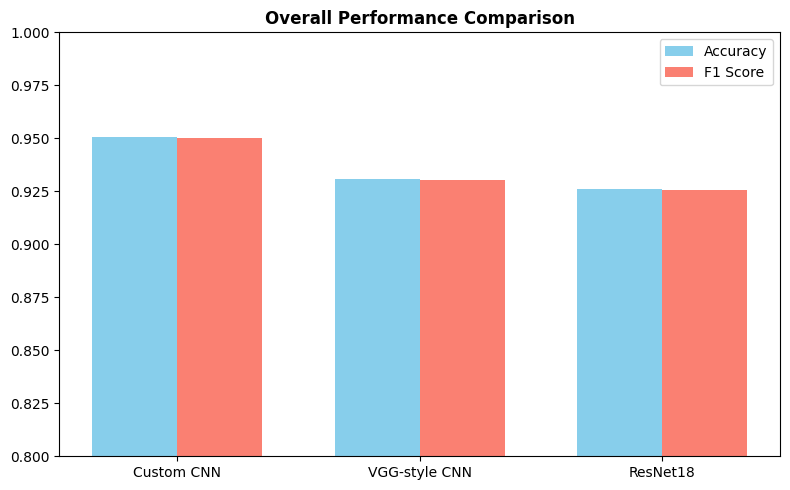

In [2]:
metrics = {}
for name, preds in preds_dict.items():
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    metrics[name] = {'Accuracy': acc, 'Weighted F1': f1}
    print(f"{name:15s} | Acc: {acc:.4f} | F1: {f1:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics))
width = 0.35
ax.bar(x - width/2, [m['Accuracy'] for m in metrics.values()], width, label='Accuracy', color='skyblue')
ax.bar(x + width/2, [m['Weighted F1'] for m in metrics.values()], width, label='F1 Score', color='salmon')
ax.set_xticks(x); ax.set_xticklabels(metrics.keys())
ax.set_ylim(0.8, 1.0)
ax.set_title('Overall Performance Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'multi_model_accuracy.png'), dpi=150)
plt.show()


## 2. Confusion Matrices Comparison

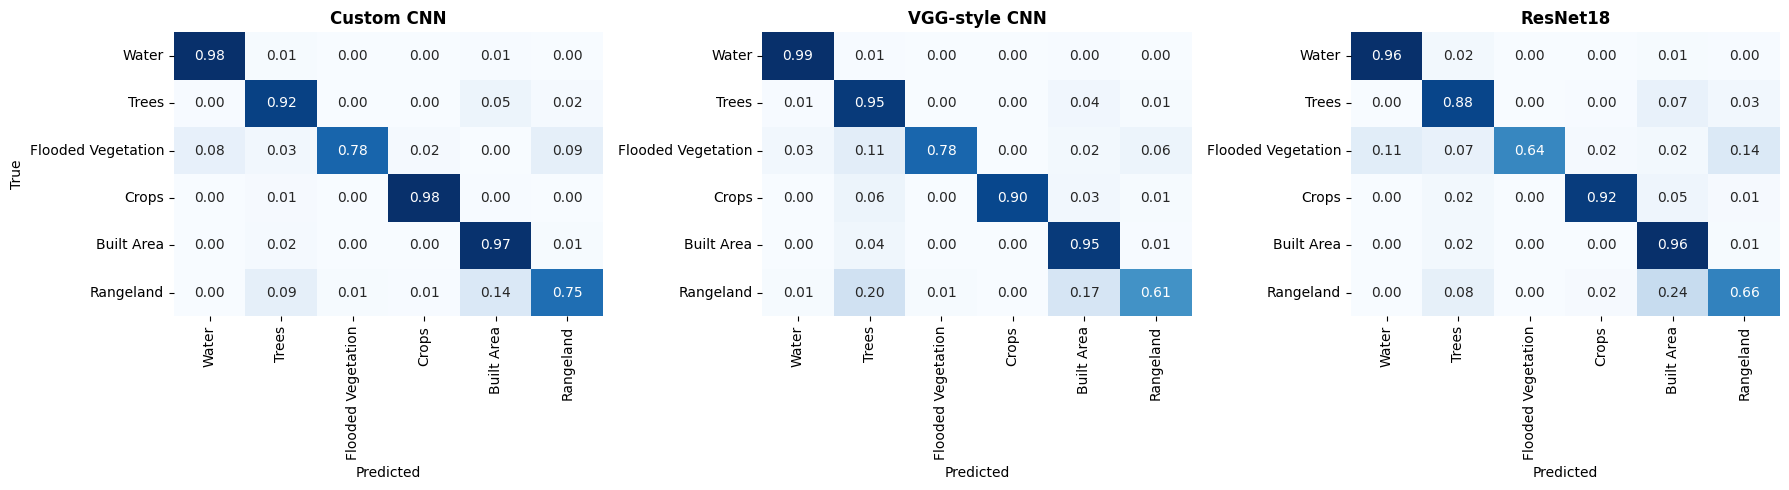

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, preds) in enumerate(preds_dict.items()):
    cm = confusion_matrix(labels, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    if i == 0: axes[i].set_ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'multi_model_confusion.png'), dpi=150)
plt.show()


## 3. Classification Reports

In [4]:
for name, preds in preds_dict.items():
    print(f"\n{'='*40}\n{name} Classification Report\n{'='*40}")
    print(classification_report(labels, preds, target_names=class_names))



Custom CNN Classification Report
                    precision    recall  f1-score   support

             Water       0.97      0.98      0.98       974
             Trees       0.92      0.92      0.92      2203
Flooded Vegetation       0.90      0.78      0.83       123
             Crops       0.96      0.98      0.97       412
        Built Area       0.97      0.97      0.97      7200
         Rangeland       0.80      0.75      0.77       599

          accuracy                           0.95     11511
         macro avg       0.92      0.90      0.91     11511
      weighted avg       0.95      0.95      0.95     11511


VGG-style CNN Classification Report
                    precision    recall  f1-score   support

             Water       0.96      0.99      0.98       974
             Trees       0.82      0.95      0.88      2203
Flooded Vegetation       0.94      0.78      0.85       123
             Crops       0.99      0.90      0.94       412
        Built Area       